# **MILESTONE-1**

In [15]:
# File handling
import os
import random

# Data handling
import numpy as np
import pandas as pd

# Audio processing
import librosa

# Visualization
import matplotlib.pyplot as plt

print("Libraries imported successfully")


Libraries imported successfully


In [17]:
# Root dataset path
DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

# Important folders
GENRES_ROOT = os.path.join(DATA_ROOT, "genres_stems")
MASHUPS_ROOT = os.path.join(DATA_ROOT, "mashups")
ESC50_ROOT = os.path.join(DATA_ROOT, "ESC-50-master")

# Competition files
TEST_CSV = os.path.join(DATA_ROOT, "test.csv")
SAMPLE_SUB = os.path.join(DATA_ROOT, "sample_submission.csv")

# Classification labels
GENRES = sorted(os.listdir(GENRES_ROOT))

print("Dataset setup complete")
print("Number of genres:", len(GENRES))
print("\nGenres:")
for g in GENRES:
    print("-", g)


Dataset setup complete
Number of genres: 10

Genres:
- blues
- classical
- country
- disco
- hiphop
- jazz
- metal
- pop
- reggae
- rock


In [18]:
# STEP 3 — Inspect one sample song
# pick first genre
sample_genre = GENRES[0]
genre_path = os.path.join(GENRES_ROOT, sample_genre)

print("Selected genre:", sample_genre)

# list songs inside this genre
songs = sorted(os.listdir(genre_path))
print("Number of songs in this genre:", len(songs))

# pick first song
sample_song = songs[0]
song_path = os.path.join(genre_path, sample_song)

print("\nSelected song:", sample_song)

# list stems inside the song
stems = sorted(os.listdir(song_path))

print("\nStems in this song:")
for s in stems:
    print("-", s)

Selected genre: blues
Number of songs in this genre: 100

Selected song: blues.00000

Stems in this song:
- bass.wav
- drums.wav
- other.wav
- vocals.wav


In [19]:

# STEP 3.1 — Load one audio file

import librosa

# choose one stem file (bass for example)
stem_path = os.path.join(song_path, "bass.wav")

# load audio
y, sr = librosa.load(stem_path, sr=None)

print("Sampling rate:", sr)
print("Number of samples:", len(y))
print("Duration (seconds):", len(y) / sr)


Sampling rate: 44100
Number of samples: 1323588
Duration (seconds): 30.013333333333332


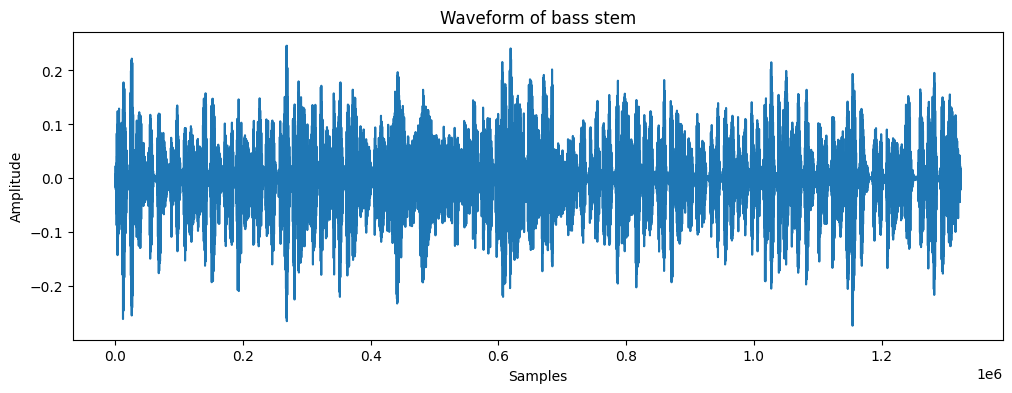

In [20]:

# STEP 3.2 — Plot waveform

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Waveform of bass stem")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [21]:
# ===============================
# STEP 4 — Build dataset dictionary
# ===============================

dataset = {}

for genre in GENRES:
    genre_path = os.path.join(GENRES_ROOT, genre)
    dataset[genre] = []

    songs = os.listdir(genre_path)

    for song in songs:
        song_path = os.path.join(genre_path, song)

        # store all stem file paths
        stems = {
            "bass": os.path.join(song_path, "bass.wav"),
            "drums": os.path.join(song_path, "drums.wav"),
            "vocals": os.path.join(song_path, "vocals.wav"),
            "other": os.path.join(song_path, "other.wav"),
        }

        dataset[genre].append(stems)

# ===============================
# CLEAN DATASET SUMMARY
# ===============================

print("Dataset summary\n")

for genre in GENRES:
    print(f"{genre}: {len(dataset[genre])} songs")

print("\nExample structure for one song:")

example = dataset[GENRES[0]][0]

for stem_name in example:
    print("-", stem_name)


Dataset summary

blues: 100 songs
classical: 100 songs
country: 100 songs
disco: 100 songs
hiphop: 100 songs
jazz: 100 songs
metal: 100 songs
pop: 100 songs
reggae: 100 songs
rock: 100 songs

Example structure for one song:
- bass
- drums
- vocals
- other


In [22]:
# ===============================
# STEP 5 — Class distribution
# ===============================

genre_counts = {genre: len(dataset[genre]) for genre in GENRES}

for genre, count in genre_counts.items():
    print(f"{genre}: {count}")


blues: 100
classical: 100
country: 100
disco: 100
hiphop: 100
jazz: 100
metal: 100
pop: 100
reggae: 100
rock: 100


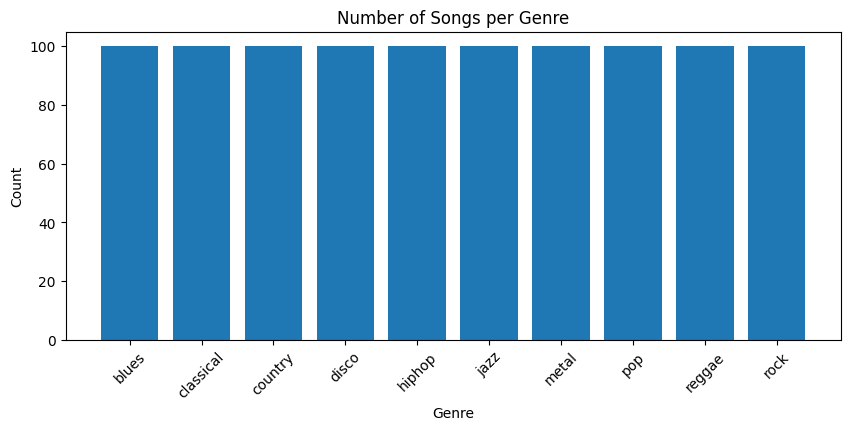

In [23]:
# ===============================
# STEP 5.1 — Plot class distribution
# ===============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(genre_counts.keys(), genre_counts.values())
plt.xticks(rotation=45)
plt.title("Number of Songs per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


✅ EDA Finding 1 — Class Distribution

we observed:

*  all bars equal height
*  each genre has 100 songs
*  dataset is perfectly balanced

In [24]:
# ===============================
# STEP 6 — Audio duration analysis
# ===============================

durations = []

for genre in GENRES:
    # sample first 10 songs from each genre
    for song in dataset[genre][:10]:
        y, sr = librosa.load(song["bass"], sr=None)
        durations.append(len(y) / sr)

print("Min duration:", min(durations))
print("Max duration:", max(durations))
print("Average duration:", sum(durations)/len(durations))


Min duration: 30.00018140589569
Max duration: 30.370975056689343
Average duration: 30.014466213151927


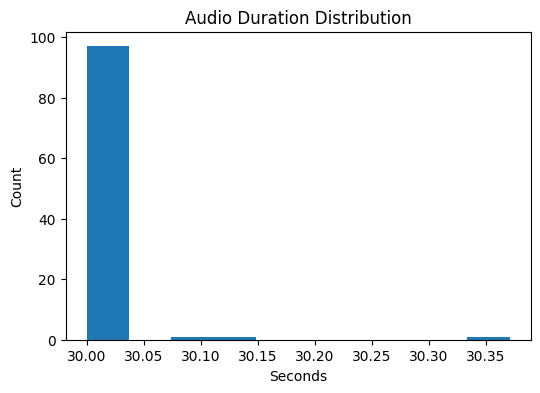

In [25]:
plt.figure(figsize=(6,4))
plt.hist(durations, bins=10)
plt.title("Audio Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()


In [26]:
import librosa
import pandas as pd

SILENCE_THRESHOLD = 5.0

silence_records = []

for genre in GENRES:
    for song in dataset[genre][:5]:
        file_path = song["vocals"]

        y, sr = librosa.load(file_path, sr=None)
        intervals = librosa.effects.split(y, top_db=20)

        if len(intervals) == 0:
            max_silence = len(y)/sr
        else:
            silences = []

            if intervals[0][0] > 0:
                silences.append(intervals[0][0]/sr)

            for i in range(len(intervals)-1):
                gap = intervals[i+1][0] - intervals[i][1]
                silences.append(gap/sr)

            if intervals[-1][1] < len(y):
                silences.append((len(y)-intervals[-1][1])/sr)

            max_silence = max(silences) if silences else 0

        if max_silence >= SILENCE_THRESHOLD:
            silence_records.append((genre, max_silence))


# ⭐ CREATE DATAFRAME (this was missing)
silence_df = pd.DataFrame(
    silence_records,
    columns=["Genre", "Max Silence (sec)"]
)


print("Files with long silence:", len(silence_df))

silence_summary = (
    silence_df.groupby("Genre")
    .agg(
        files_with_silence=("Genre", "count"),
        avg_silence=("Max Silence (sec)", "mean"),
        max_silence=("Max Silence (sec)", "max")
    )
    .round(2)
    .reset_index()
)

print("\nSilence summary by genre:\n")
display(silence_summary)


Files with long silence: 19

Silence summary by genre:



,Genre,files_with_silence,avg_silence,max_silence
0,blues,3,9.47,10.13
1,classical,5,19.13,23.70
2,hiphop,1,7.74,7.74
3,jazz,5,19.32,28.85
4,metal,3,7.56,9.95
5,rock,2,7.88,8.86


In [28]:
# ===============================
# FULL DATASET SILENCE SUMMARY (FIXED)
# ===============================

import pandas as pd
from collections import defaultdict

SILENCE_THRESHOLD = 5.0
silence_count = defaultdict(int)

for genre in GENRES:
    for song in dataset[genre]:
        y, sr = librosa.load(song["vocals"], sr=None)
        intervals = librosa.effects.split(y, top_db=20)

        gaps = []
        if len(intervals) == 0:
            gaps = [len(y)/sr]
        else:
            if intervals[0][0] > 0:
                gaps.append(intervals[0][0]/sr)

            for i in range(len(intervals)-1):
                gaps.append((intervals[i+1][0] - intervals[i][1]) / sr)

            if intervals[-1][1] < len(y):
                gaps.append((len(y)-intervals[-1][1]) / sr)

        max_silence = max(gaps) if gaps else 0

        if max_silence >= SILENCE_THRESHOLD:
            silence_count[genre] += 1

silence_summary = pd.DataFrame({
    "Genre": GENRES,
    "Files with long silence": [silence_count[g] for g in GENRES]
}).sort_values("Files with long silence", ascending=False)

display(silence_summary)


,Genre,Files with long silence
5,jazz,87
1,classical,86
0,blues,54
6,metal,48
9,rock,29
3,disco,21
2,country,20
8,reggae,17
4,hiphop,6
7,pop,5


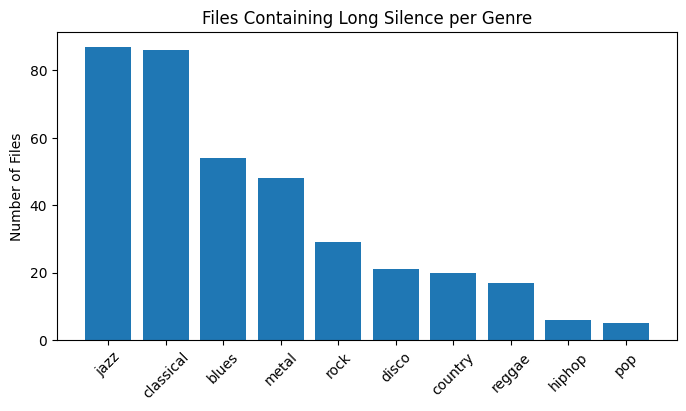

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(
    silence_summary["Genre"],
    silence_summary["Files with long silence"]
)
plt.xticks(rotation=45)
plt.title("Files Containing Long Silence per Genre")
plt.ylabel("Number of Files")
plt.show()


In [33]:
ESC_AUDIO = os.path.join(ESC50_ROOT, "audio")

esc_files = sorted(os.listdir(ESC_AUDIO))

print("Total ESC-50 audio files:", len(esc_files))
print("\nFirst 10 files:")
for f in esc_files[:10]:
    print("-", f)


Total ESC-50 audio files: 2000

First 10 files:
- 1-100032-A-0.wav
- 1-100038-A-14.wav
- 1-100210-A-36.wav
- 1-100210-B-36.wav
- 1-101296-A-19.wav
- 1-101296-B-19.wav
- 1-101336-A-30.wav
- 1-101404-A-34.wav
- 1-103298-A-9.wav
- 1-103995-A-30.wav


In [34]:
noise_path = os.path.join(ESC_AUDIO, esc_files[0])

y_noise, sr_noise = librosa.load(noise_path, sr=None)

print("Sampling rate:", sr_noise)
print("Duration (sec):", len(y_noise)/sr_noise)


Sampling rate: 44100
Duration (sec): 5.0


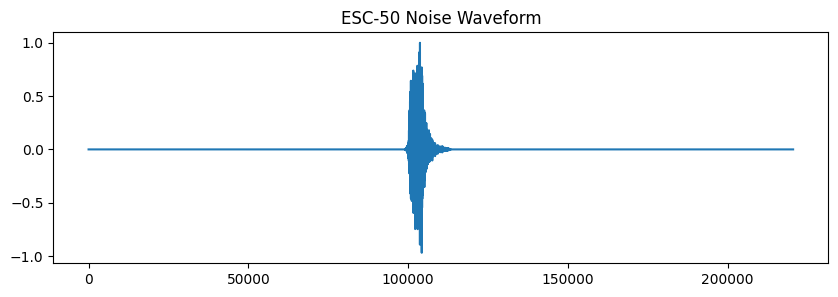

In [35]:
plt.figure(figsize=(10,3))
plt.plot(y_noise)
plt.title("ESC-50 Noise Waveform")
plt.show()


In [36]:
# ===============================
# STEP 9 — Random baseline submission
# ===============================

import pandas as pd
import numpy as np

# load test file
test_df = pd.read_csv(TEST_CSV)

# random predictions
random_preds = np.random.choice(GENRES, size=len(test_df))

# build submission
submission = pd.DataFrame({
    "id": test_df["id"],
    "genre": random_preds
})

# save file
submission.to_csv("submission.csv", index=False)

print("Submission file created!")
submission.head()


Submission file created!


,id,genre
0,1,country
1,2,hiphop
2,3,rock
3,4,metal
4,5,pop
